In [31]:
install.packages('sqldf')
install.packages('dplyr')
install.packages('ggplot2')
library(sqldf)
library(dplyr)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [58]:
BASE <- "/content/northstar_dataset/"

orders <- read.csv(paste0(BASE, "orders.csv"))
deliveries <- read.csv(paste0(BASE, "deliveries.csv"))
customers <- read.csv(paste0(BASE, "customers.csv"))
drivers <- read.csv(paste0(BASE, "drivers.csv"))
vehicles <- read.csv(paste0(BASE, "vehicles.csv"))
hubs <- read.csv(paste0(BASE, "hubs.csv"))
incidents <- read.csv(paste0(BASE, "incidents.csv"))
complaints <- read.csv(paste0(BASE, "complaints.csv"))
app_events <- read.csv(paste0(BASE, "app_events.csv"))

In [67]:
# QUERY - 1. DELIVERY STATUS DISTRIBUTION BY HUB

result1 <- sqldf("
SELECT
    d.hub_id,
    h.hub_name,
    h.zone,
    d.delivery_status,
    COUNT(*) AS total_count
FROM deliveries d
JOIN hubs h
ON d.hub_id = h.hub_id
GROUP BY d.hub_id, h.hub_name, h.zone, d.delivery_status
ORDER BY total_count DESC
")

print(result1)

cat("
BUSINESS INTERPRETATION:
This query identifies which hubs experience the highest number
of failed and late deliveries. Hubs with unusually high failure
rates may suffer from poor operational planning, inefficient
dispatch management, or resource shortages.
")

   hub_id       hub_name      zone delivery_status total_count
1     H01 North Exchange     North          OnTime          93
2     H03      East Dock      East          OnTime          85
3     H04      West Gate      West          OnTime          83
4     H08  Midtown Relay   Central          OnTime          80
5     H07  Riverside Hub Riverside          OnTime          76
6     H02     South Link     South          OnTime          70
7     H05   Central Core   Central          OnTime          67
8     H06    Airport Hub   Airport          OnTime          62
9     H04      West Gate      West         Delayed          28
10    H06    Airport Hub   Airport         Delayed          27
11    H01 North Exchange     North         Delayed          26
12    H02     South Link     South         Delayed          26
13    H08  Midtown Relay   Central          Failed          26
14    H05   Central Core   Central         Delayed          25
15    H07  Riverside Hub Riverside         Delayed     

In [68]:
# QUERY - 2. DRIVER ROUTE OVERRIDE ANALYSIS

result2 <- sqldf("
SELECT
    d.driver_id,
    dr.base_zone,
    dr.employment_type,
    COUNT(*) AS total_deliveries,
    SUM(d.manual_route_override_count) AS total_overrides,
    ROUND(AVG(d.manual_route_override_count),2) AS avg_overrides,
    ROUND(AVG(d.customer_rating_post_delivery),2) AS avg_rating
FROM deliveries d
JOIN drivers dr
ON d.driver_id = dr.driver_id
GROUP BY d.driver_id, dr.base_zone, dr.employment_type
HAVING total_deliveries >= 3
ORDER BY avg_overrides DESC
LIMIT 20
")

print(result2)

cat("
BUSINESS INTERPRETATION:
Drivers with excessive route overrides may indicate poor route
allocation systems or possible attempts to bypass performance targets.
Lower customer ratings may also be linked to route inefficiencies.
")

   driver_id base_zone employment_type total_deliveries total_overrides
1       D127   CENTRAL        FullTime                6              17
2       D062     South        FullTime                3               6
3       D069     NORTH        PartTime                7              14
4       D085     North        PartTime                4               8
5       D105 RiverSide        Contract                7              14
6       D124     north        FullTime                4               8
7       D130      WEST        FullTime                8              16
8       D139     South        FullTime                5              10
9       D028     North        FullTime                7              13
10      D027   AIRPORT        PartTime                6              11
11      D143   CENTRAL        FullTime                5               9
12      D003   AIRPORT        FullTime                4               7
13      D107 RiverSide        FullTime                4         

In [69]:
# QUERY - 3. CUSTOMERS WITH REPEATED COMPLAINTS

result3 <- sqldf("
SELECT
    c.customer_id,
    c.home_zone,
    c.customer_type,
    COUNT(DISTINCT cp.complaint_id) AS complaint_count,
    COUNT(DISTINCT CASE
        WHEN d.delivery_status='Failed'
        THEN d.delivery_id
    END) AS failed_deliveries,
    SUM(cp.compensation_amount) AS total_compensation
FROM customers c
LEFT JOIN complaints cp
ON c.customer_id = cp.customer_id
LEFT JOIN orders o
ON c.customer_id = o.customer_id
LEFT JOIN deliveries d
ON o.order_id = d.order_id
GROUP BY c.customer_id, c.home_zone, c.customer_type
HAVING complaint_count >= 2
ORDER BY complaint_count DESC
LIMIT 20
")

print(result3)

cat("
BUSINESS INTERPRETATION:
Customers with repeated complaints and failed deliveries are at
high risk of churn. These cases indicate service quality issues
that directly affect customer satisfaction and retention.
")

   customer_id home_zone customer_type complaint_count failed_deliveries
1        C0368     North      Consumer               4                 1
2        C0110      EAST      Consumer               3                 1
3        C0142     SOUTH      Consumer               3                 0
4        C0172     north      Consumer               3                 0
5        C0191     North      Consumer               3                 0
6        C0242      East      Consumer               3                 0
7        C0282 RiverSide      Consumer               3                 1
8        C0372      West      Consumer               3                 1
9        C0421   CENTRAL      Consumer               3                 0
10       C0545     SOUTH      Consumer               3                 0
11       C0573   AIRPORT           SME               3                 1
12       C0626     SOUTH      Consumer               3                 0
13       C0001     North           SME             

In [73]:
# QUERY - 4. BATTERY HEALTH VS INCIDENT RATE

result4 <- sqldf("
SELECT
    CASE
        WHEN v.battery_health_pct >= 80 THEN 'Good'
        WHEN v.battery_health_pct >= 60 THEN 'Fair'
        ELSE 'Poor'
    END AS battery_band,

    COUNT(DISTINCT v.vehicle_id) AS vehicle_count,
    COUNT(i.incident_id) AS total_incidents,
    ROUND(AVG(i.resolved_hours),2) AS avg_resolution_time

FROM vehicles v

JOIN deliveries d
ON v.vehicle_id = d.vehicle_id

LEFT JOIN incidents i
ON d.delivery_id = i.delivery_id

GROUP BY battery_band
")

print(result4)

cat("
BUSINESS INTERPRETATION:
Vehicles with lower battery health may experience more operational
failures and incidents. This suggests that predictive maintenance
strategies are necessary to improve service reliability.
")


  battery_band vehicle_count total_incidents avg_resolution_time
1         Fair            56             121               12.82
2         Good            47             115               11.41
3         Poor            17              44               11.31

BUSINESS INTERPRETATION:
Vehicles with lower battery health may experience more operational
failures and incidents. This suggests that predictive maintenance
strategies are necessary to improve service reliability.


In [72]:
# QUERY - 5. SERVICE PROFITABILITY ANALYSIS

result5 <- sqldf("
SELECT
    o.pickup_zone,
    o.service_type,

    COUNT(o.order_id) AS order_count,

    ROUND(AVG(o.order_value),2) AS avg_order_value,

    ROUND(AVG(d.fuel_or_charge_cost),2) AS avg_fuel_cost,

    ROUND(
        AVG(o.order_value - d.fuel_or_charge_cost),2
    ) AS avg_net_margin,

    ROUND(AVG(d.route_distance_km),2) AS avg_distance

FROM orders o

JOIN deliveries d
ON o.order_id = d.order_id

GROUP BY o.pickup_zone, o.service_type

ORDER BY avg_net_margin ASC
")

print(result5)

cat("
BUSINESS INTERPRETATION:
Zones with low net margins are potentially unprofitable.
Management can use this information to optimise pricing,
delivery routing, and resource allocation.
")

   pickup_zone service_type order_count avg_order_value avg_fuel_cost
1         West     Business           7           53.95         13.15
2         East      Medical           9           52.86         11.89
3          Ctr      Medical           2           53.92         11.13
4        north      Medical           7           57.49         14.17
5      AIRPORT     Business           5           66.61         18.22
6      Central    Passenger          20           61.75         11.90
7    RiverSide       Parcel          17           68.07         13.28
8        North       Parcel           8           67.15         10.84
9         East       Retail          20           69.57         11.73
10        West       Retail           8           70.02         10.40
11        EAST     Business           7           73.71         12.96
12   RiverSide    Passenger          19           73.98         13.17
13        WEST       Retail          14           74.22         11.62
14     Central      

In [65]:
# QUERY OPTIMISATION

cat("BEFORE OPTIMISATION\n")

system.time({
slow_query <- sqldf("
SELECT *
FROM deliveries d
JOIN orders o
ON d.order_id = o.order_id
WHERE d.delivery_status='Failed'
")
})

cat("AFTER OPTIMISATION\n")

failed_only <- deliveries[
    deliveries$delivery_status == "Failed", ]

system.time({
fast_query <- sqldf("
SELECT *
FROM failed_only f
JOIN orders o
ON f.order_id = o.order_id
")
})

cat("
OPTIMISATION EXPLANATION:
Filtering failed deliveries before joining reduces the number
of rows processed by SQLite. This improves query efficiency
because fewer records are scanned during execution.
")

BEFORE OPTIMISATION


   user  system elapsed 
  0.082   0.013   0.103 

AFTER OPTIMISATION


   user  system elapsed 
  0.071   0.008   0.085 


OPTIMISATION EXPLANATION:
Filtering failed deliveries before joining reduces the number
of rows processed by SQLite. This improves query efficiency
because fewer records are scanned during execution.


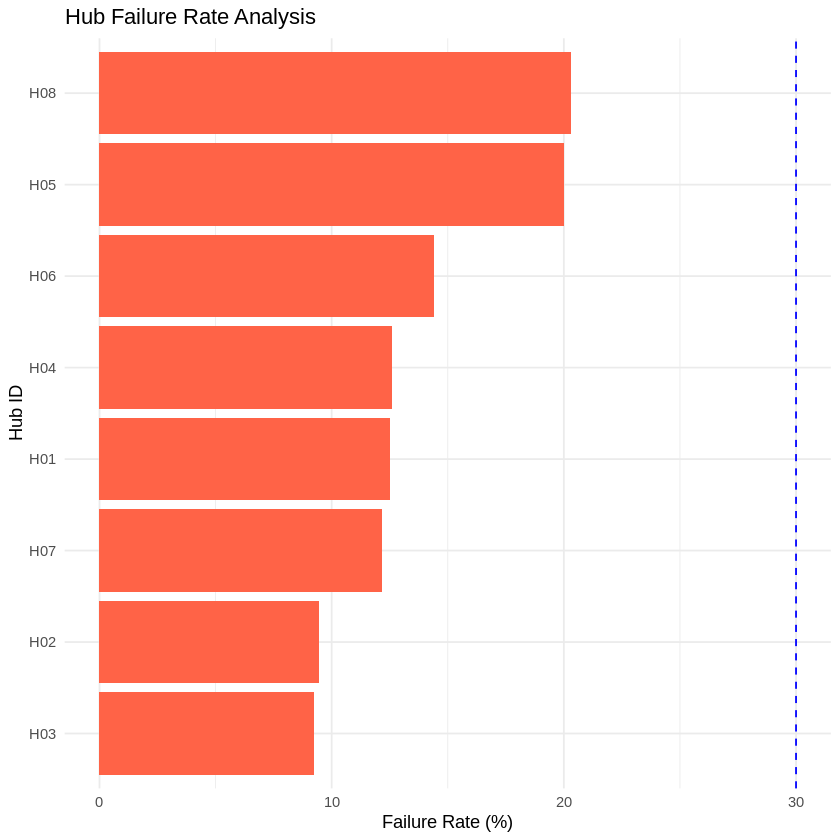

In [66]:
# VISUALISATION - HUB FAILURE RATE

hub_fail <- deliveries %>%
  group_by(hub_id) %>%
  summarise(
    total = n(),
    failed = sum(delivery_status == "Failed")
  )

hub_fail$failure_rate <-
  (hub_fail$failed / hub_fail$total) * 100

ggplot(hub_fail,
       aes(x=reorder(hub_id, failure_rate),
           y=failure_rate)) +

geom_bar(stat="identity", fill="tomato") +

geom_hline(yintercept=30,
           colour="blue",
           linetype="dashed") +

coord_flip() +

labs(
  title="Hub Failure Rate Analysis",
  x="Hub ID",
  y="Failure Rate (%)"
) +

theme_minimal()